In [2]:
import os

DATASET_PATH = "parking_dataset"

print("Dataset contents:")
print(os.listdir(DATASET_PATH))

Dataset contents:
['parking_crop_loop.mp4', '.DS_Store', 'parking_crop.mp4', 'mask_crop.png', 'util.py', 'parking_1920_1080.mp4', 'model', 'parking_1920_1080_loop.mp4', 'clf-data', 'mask_1920_1080.png']


In [3]:
for root, folders, files in os.walk(DATASET_PATH):
    print("\nFolder:", root)

    if folders:
        print("Subfolders:", folders)

    if files:
        print("Files:", files)


Folder: parking_dataset
Subfolders: ['model', 'clf-data']
Files: ['parking_crop_loop.mp4', '.DS_Store', 'parking_crop.mp4', 'mask_crop.png', 'util.py', 'parking_1920_1080.mp4', 'parking_1920_1080_loop.mp4', 'mask_1920_1080.png']

Folder: parking_dataset/model
Files: ['model.p']

Folder: parking_dataset/clf-data
Subfolders: ['empty', 'not_empty']
Files: ['.DS_Store']

Folder: parking_dataset/clf-data/empty
Files: ['00000010_00000004.jpg', '00000600_00000179.jpg', '00000700_00000223.jpg', '00000510_00000303.jpg', '00000130_00000157.jpg', '00000150_00000029.jpg', '00000680_00000061.jpg', '00000540_00000091.jpg', '00000260_00000072.jpg', '00000830_00000224.jpg', '00000100_00000344.jpg', '00000130_00000180.jpg', '00000500_00000319.jpg', '00000110_00000389.jpg', '00000460_00000129.jpg', '00000290_00000032.jpg', '00000040_00000341.jpg', '00000300_00000281.jpg', '00000790_00000335.jpg', '00000070_00000185.jpg', '00000580_00000201.jpg', '00000290_00000026.jpg', '00000080_00000106.jpg', '000001

In [4]:
import os

DATASET_PATH = "parking_dataset"

for item in os.listdir(DATASET_PATH):
    path = os.path.join(DATASET_PATH, item)

    if os.path.isdir(path):
        print("📁 FOLDER:", item)
    else:
        print("📄 FILE:  ", item)

📄 FILE:   parking_crop_loop.mp4
📄 FILE:   .DS_Store
📄 FILE:   parking_crop.mp4
📄 FILE:   mask_crop.png
📄 FILE:   util.py
📄 FILE:   parking_1920_1080.mp4
📁 FOLDER: model
📄 FILE:   parking_1920_1080_loop.mp4
📁 FOLDER: clf-data
📄 FILE:   mask_1920_1080.png


In [5]:
import cv2
import matplotlib.pyplot as plt
import os

MASK_PATH = os.path.join(
    DATASET_PATH,
    "mask_1920_1080.png"
)

mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)

print("Mask loaded:", mask is not None)
print("Mask shape:", mask.shape)

Mask loaded: True
Mask shape: (1080, 1920)


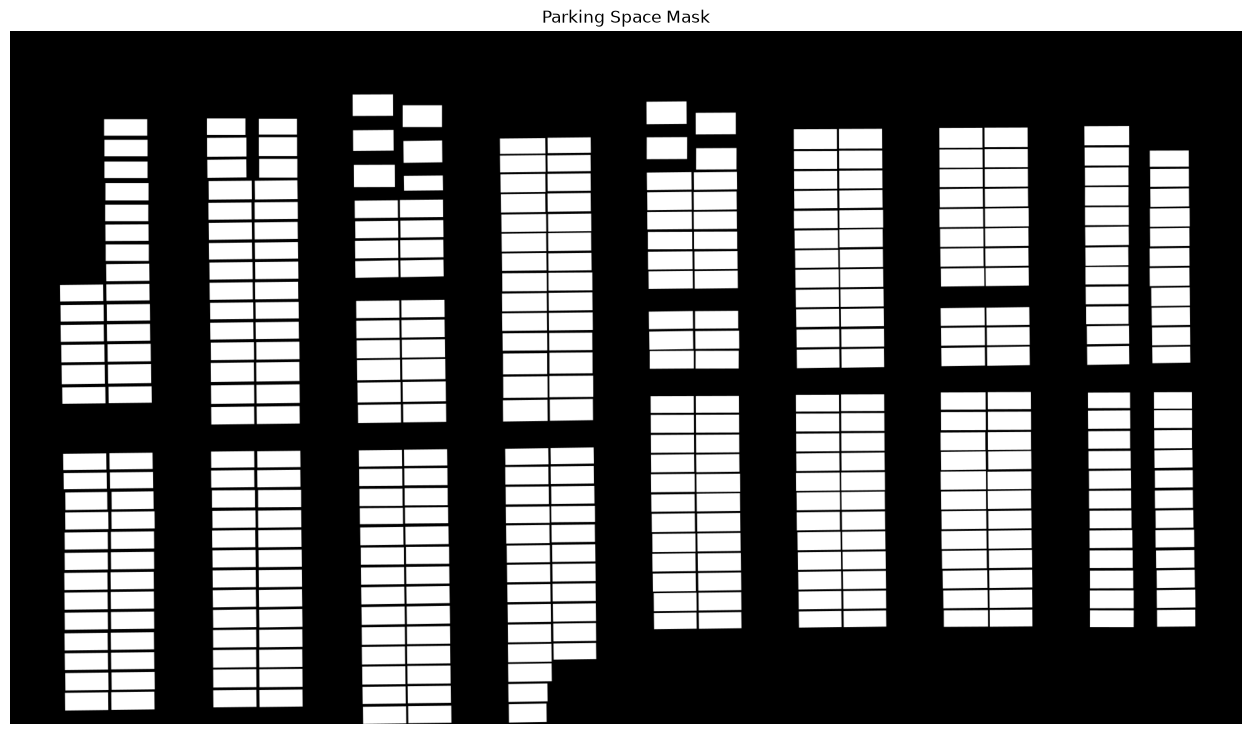

In [6]:
plt.figure(figsize=(16, 9))

plt.imshow(mask, cmap="gray")
plt.title("Parking Space Mask")
plt.axis("off")

plt.show()

In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob

In [8]:
DATASET_PATH = "parking_dataset"

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset path: parking_dataset
Dataset exists: True


In [9]:
for item in os.listdir(DATASET_PATH):
    path = os.path.join(DATASET_PATH, item)

    if os.path.isdir(path):
        print("📁 FOLDER:", item)
    else:
        print("📄 FILE: ", item)

📄 FILE:  parking_crop_loop.mp4
📄 FILE:  .DS_Store
📄 FILE:  parking_crop.mp4
📄 FILE:  mask_crop.png
📄 FILE:  util.py
📄 FILE:  parking_1920_1080.mp4
📁 FOLDER: model
📄 FILE:  parking_1920_1080_loop.mp4
📁 FOLDER: clf-data
📄 FILE:  mask_1920_1080.png


In [10]:
VIDEO_PATH = os.path.join(
    DATASET_PATH,
    "parking_1920_1080.mp4"
)

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    print("Unable to open video.")
else:
    print("Video opened successfully.")

Video opened successfully.


In [11]:
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frame_count / fps if fps > 0 else 0

print("Number of frames:", frame_count)
print("FPS:", fps)
print("Width:", width)
print("Height:", height)
print("Duration:", round(duration, 2), "seconds")

Number of frames: 849
FPS: 30.0
Width: 1920
Height: 1080
Duration: 28.3 seconds


In [12]:
video_info = pd.DataFrame({
    "Property": [
        "Number of Frames",
        "FPS",
        "Width",
        "Height",
        "Duration (seconds)"
    ],
    "Value": [
        frame_count,
        fps,
        width,
        height,
        duration
    ]
})

video_info

,Property,Value
0,Number of Frames,849.0
1,FPS,30.0
2,Width,1920.0
3,Height,1080.0
4,Duration (seconds),28.3


In [13]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

success, frame = cap.read()

print("Frame successfully extracted:", success)

if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    print("Frame shape:", frame_rgb.shape)

Frame successfully extracted: True
Frame shape: (1080, 1920, 3)


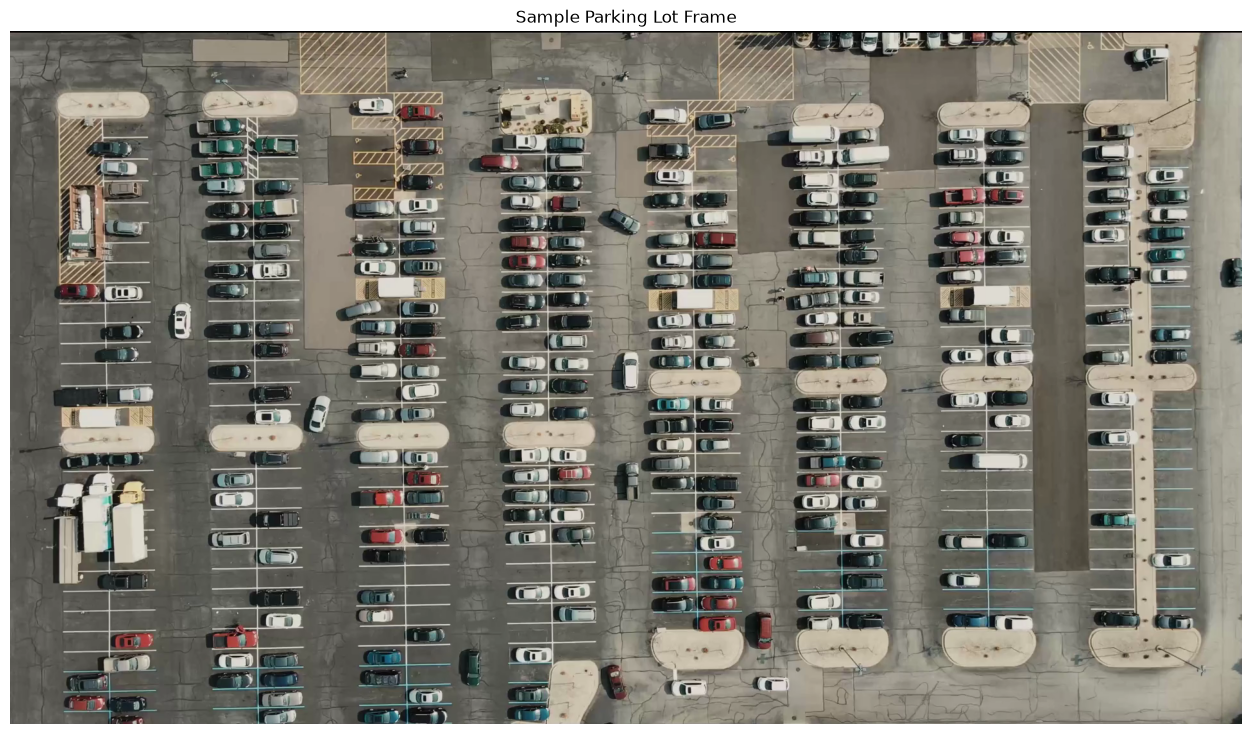

In [14]:
plt.figure(figsize=(16, 9))

plt.imshow(frame_rgb)
plt.title("Sample Parking Lot Frame")
plt.axis("off")

plt.show()

In [15]:
sample_positions = np.linspace(
    0,
    frame_count - 1,
    6,
    dtype=int
)

sample_frames = []

for position in sample_positions:

    cap.set(cv2.CAP_PROP_POS_FRAMES, position)

    success, frame = cap.read()

    if success:
        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        sample_frames.append(frame)

print("Number of sampled frames:", len(sample_frames))

Number of sampled frames: 6


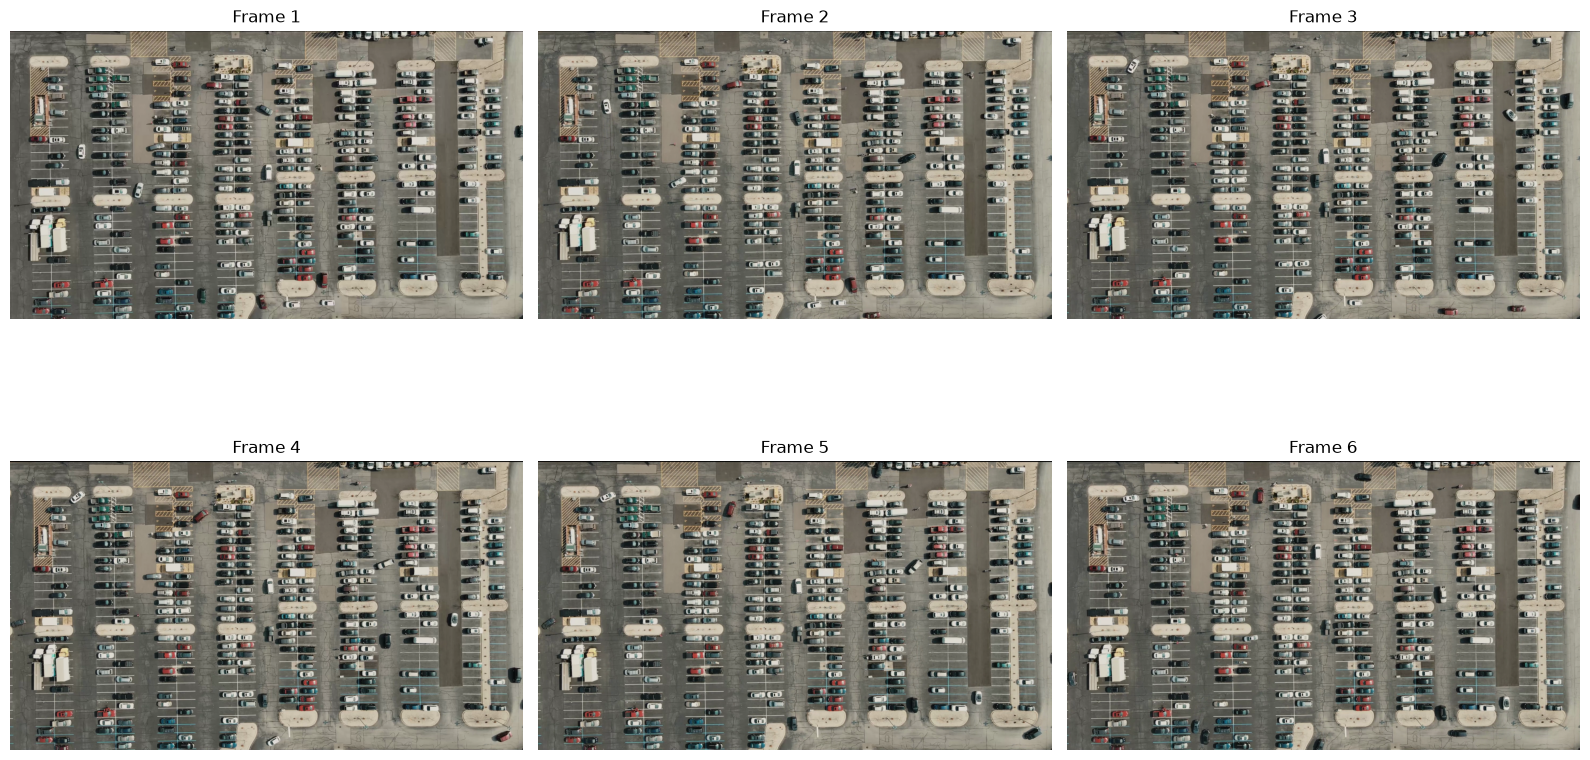

In [16]:
plt.figure(figsize=(16, 10))

for i, image in enumerate(sample_frames):

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
brightness_values = []

for image in sample_frames:

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    brightness = np.mean(gray)

    brightness_values.append(brightness)

print("Brightness values:")
print(brightness_values)

Brightness values:
[np.float64(116.55932291666667), np.float64(117.15822530864197), np.float64(116.65422405478395), np.float64(116.51232397762345), np.float64(116.48978491512345), np.float64(116.52227189429013)]


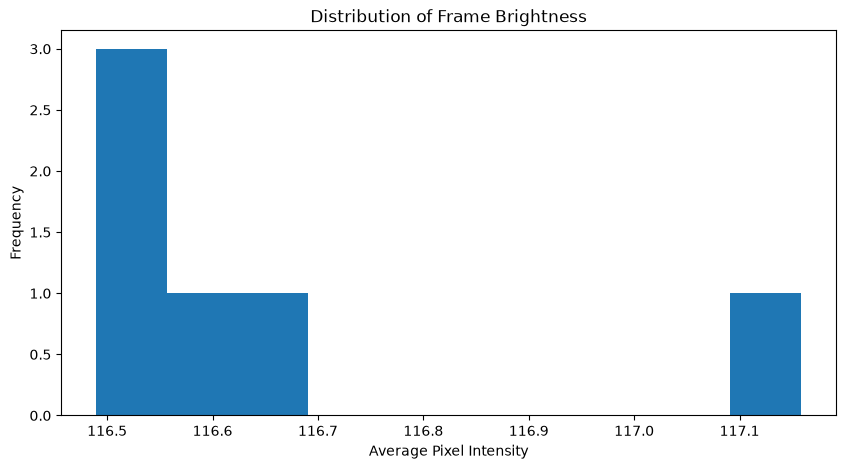

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    brightness_values,
    bins=10
)

plt.title("Distribution of Frame Brightness")
plt.xlabel("Average Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [19]:
MASK_PATH = os.path.join(
    DATASET_PATH,
    "mask_1920_1080.png"
)

mask = cv2.imread(
    MASK_PATH,
    cv2.IMREAD_GRAYSCALE
)

print("Mask loaded:", mask is not None)

if mask is not None:
    print("Mask shape:", mask.shape)

Mask loaded: True
Mask shape: (1080, 1920)


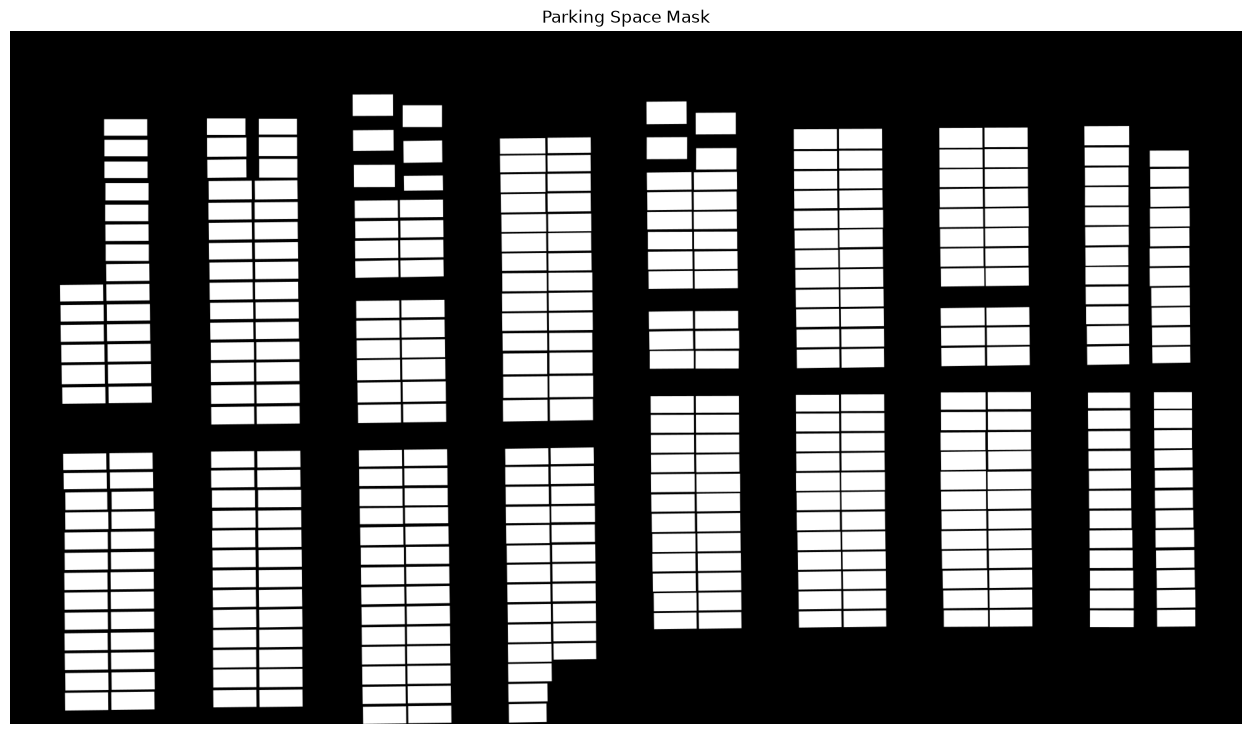

In [20]:
plt.figure(figsize=(16, 9))

plt.imshow(
    mask,
    cmap="gray"
)

plt.title("Parking Space Mask")
plt.axis("off")

plt.show()

In [21]:
unique_values, counts = np.unique(
    mask,
    return_counts=True
)

mask_statistics = pd.DataFrame({
    "Pixel Value": unique_values,
    "Count": counts
})

mask_statistics

,Pixel Value,Count
0,0,1309789
1,1,206
2,2,136
3,3,116
4,4,130
...,...,...
251,251,169
252,252,121
253,253,121
254,254,232


In [22]:
parking_pixels = np.sum(mask > 0)
total_pixels = mask.size

parking_percentage = (
    parking_pixels / total_pixels
) * 100

print(
    f"Parking-space mask covers approximately "
    f"{parking_percentage:.2f}% of the image."
)

Parking-space mask covers approximately 36.84% of the image.


In [23]:
binary_mask = np.where(
    mask > 0,
    255,
    0
).astype(np.uint8)

print("Binary mask created.")

Binary mask created.


In [24]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    binary_mask,
    connectivity=8
)

print("Connected regions detected:", num_labels - 1)

Connected regions detected: 396


In [25]:
parking_regions = []

for i in range(1, num_labels):

    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    parking_regions.append({
        "Region_ID": i,
        "X": x,
        "Y": y,
        "Width": w,
        "Height": h,
        "Area": area
    })

parking_df = pd.DataFrame(
    parking_regions
)

parking_df.head()

,Region_ID,X,Y,Width,Height,Area
0,1,533,98,65,35,2208
1,2,991,109,64,37,2291
2,3,611,115,63,35,2203
3,4,1068,127,64,35,2205
4,5,146,137,68,27,1836


In [26]:
parking_df.describe()

,Region_ID,X,Y,Width,Height,Area
count,396.0000,396.000000,396.000000,396.000000,396.000000,396.000000
mean,198.5000,900.431818,570.270202,67.936869,29.179293,1928.815657
std,114.4596,519.212362,255.060678,2.344626,1.662901,119.904219
min,1.0000,77.000000,98.000000,60.000000,24.000000,1477.000000
25%,99.7500,388.000000,343.000000,68.000000,28.000000,1872.000000
50%,198.5000,841.500000,573.500000,68.000000,29.000000,1928.000000
75%,297.2500,1295.250000,780.500000,69.000000,30.000000,1981.000000
max,396.0000,1787.000000,1052.000000,72.000000,37.000000,2382.000000


In [27]:
MIN_AREA = 100

parking_df = parking_df[
    parking_df["Area"] >= MIN_AREA
].reset_index(drop=True)

print(
    "Parking regions after filtering:",
    len(parking_df)
)

Parking regions after filtering: 396


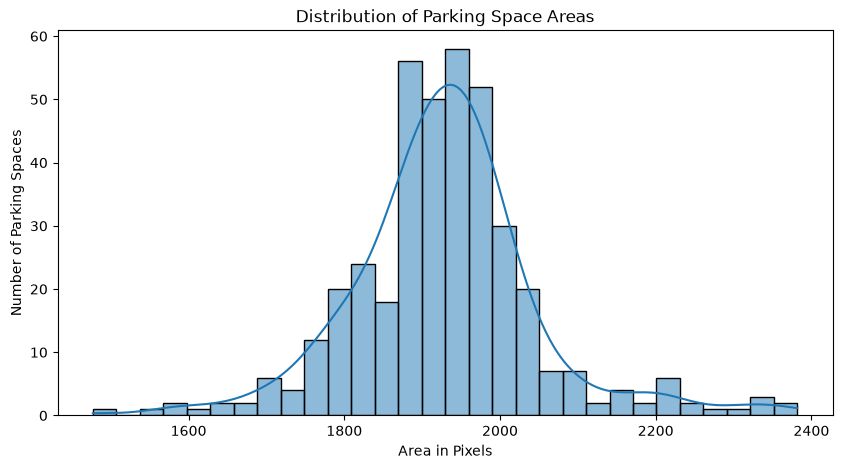

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    parking_df["Area"],
    bins=30,
    kde=True
)

plt.title("Distribution of Parking Space Areas")
plt.xlabel("Area in Pixels")
plt.ylabel("Number of Parking Spaces")

plt.show()

In [29]:
visualization = frame_rgb.copy()

for _, row in parking_df.iterrows():

    x = int(row["X"])
    y = int(row["Y"])
    w = int(row["Width"])
    h = int(row["Height"])

    cv2.rectangle(
        visualization,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

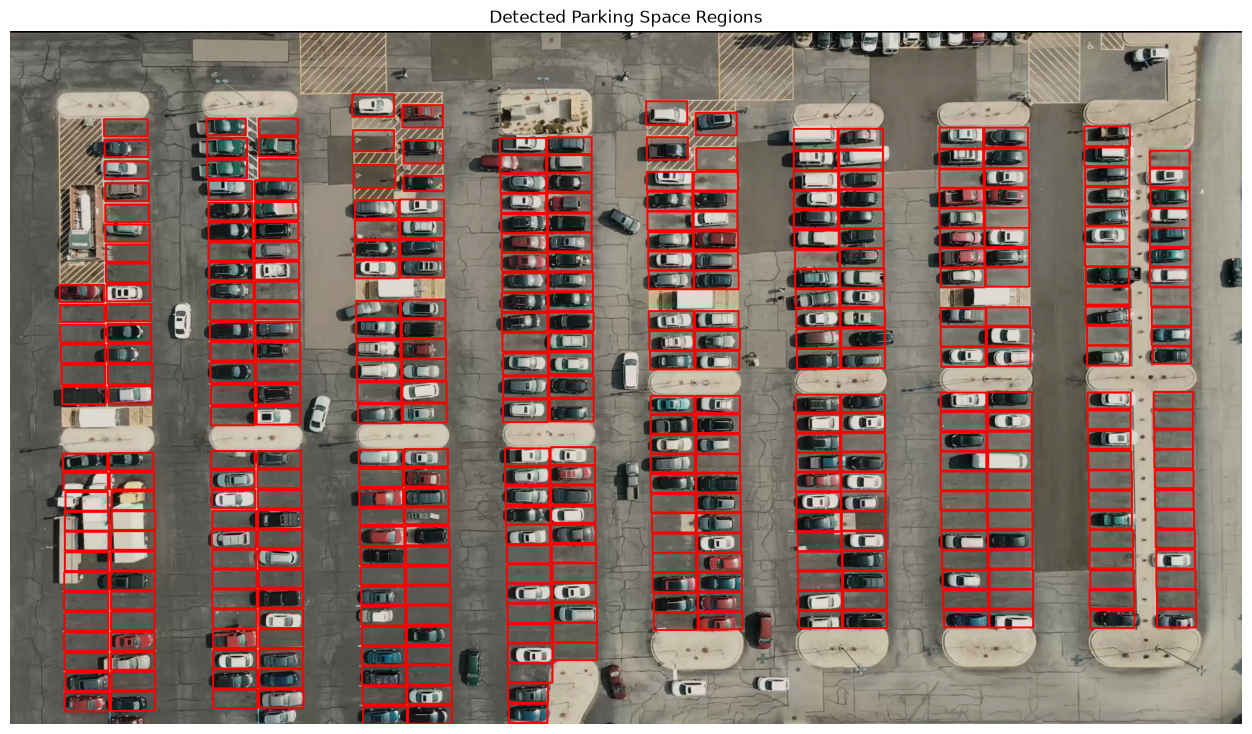

In [30]:
plt.figure(figsize=(16, 9))

plt.imshow(visualization)

plt.title(
    "Detected Parking Space Regions"
)

plt.axis("off")

plt.show()

In [31]:
parking_crops = []

original_frame = cv2.cvtColor(
    frame_rgb,
    cv2.COLOR_RGB2BGR
)

for _, row in parking_df.iterrows():

    x = int(row["X"])
    y = int(row["Y"])
    w = int(row["Width"])
    h = int(row["Height"])

    crop = original_frame[
        y:y+h,
        x:x+w
    ]

    if crop.size > 0:

        parking_crops.append(crop)

print(
    "Extracted parking-space crops:",
    len(parking_crops)
)

Extracted parking-space crops: 396


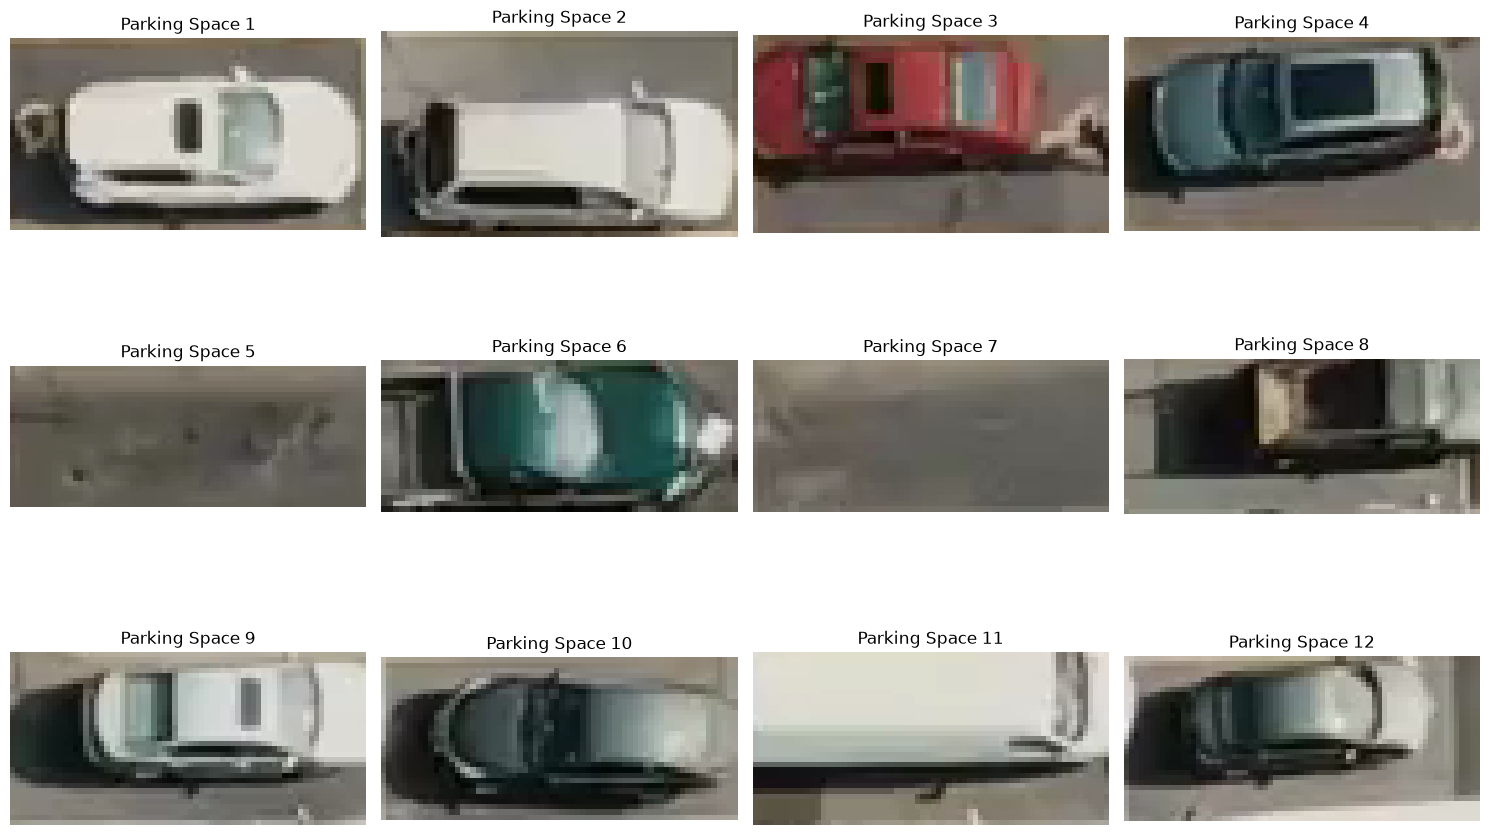

In [32]:
num_display = min(
    12,
    len(parking_crops)
)

plt.figure(figsize=(15, 10))

for i in range(num_display):

    crop_rgb = cv2.cvtColor(
        parking_crops[i],
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(3, 4, i + 1)

    plt.imshow(crop_rgb)

    plt.title(
        f"Parking Space {i + 1}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
IMG_SIZE = (128, 128)

resized_crops = []

for crop in parking_crops:

    resized = cv2.resize(
        crop,
        IMG_SIZE
    )

    resized_crops.append(resized)

print(
    "Number of resized crops:",
    len(resized_crops)
)

print(
    "Example shape:",
    resized_crops[0].shape
)

Number of resized crops: 396
Example shape: (128, 128, 3)


In [34]:
normalized_crops = []

for image in resized_crops:

    normalized = (
        image.astype(np.float32) / 255.0
    )

    normalized_crops.append(
        normalized
    )

normalized_crops = np.array(
    normalized_crops
)

print(
    "Normalized data shape:",
    normalized_crops.shape
)

print(
    "Minimum pixel value:",
    normalized_crops.min()
)

print(
    "Maximum pixel value:",
    normalized_crops.max()
)

Normalized data shape: (396, 128, 128, 3)
Minimum pixel value: 0.0
Maximum pixel value: 0.99607843


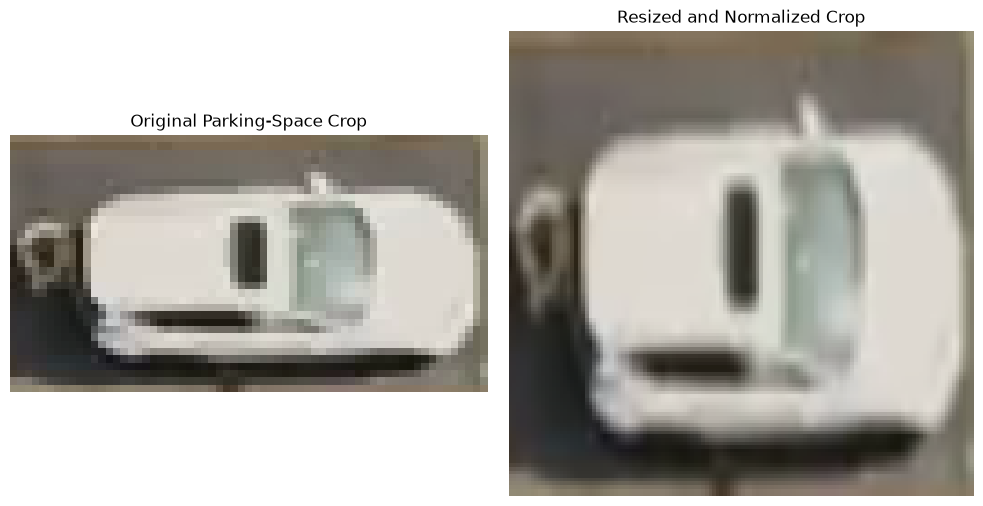

In [35]:
original = cv2.cvtColor(
    parking_crops[0],
    cv2.COLOR_BGR2RGB
)

processed = cv2.cvtColor(
    normalized_crops[0],
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(original)

plt.title("Original Parking-Space Crop")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(processed)

plt.title("Resized and Normalized Crop")

plt.axis("off")

plt.tight_layout()

plt.show()

In [36]:
summary = pd.DataFrame({
    "Dataset Property": [
        "Video Width",
        "Video Height",
        "Video FPS",
        "Video Frames",
        "Video Duration (seconds)",
        "Mask Width",
        "Mask Height",
        "Parking Regions",
        "CNN Image Width",
        "CNN Image Height",
        "Pixel Range After Normalization"
    ],

    "Value": [
        width,
        height,
        round(fps, 2),
        frame_count,
        round(duration, 2),
        mask.shape[1],
        mask.shape[0],
        len(parking_df),
        IMG_SIZE[0],
        IMG_SIZE[1],
        "0–1"
    ]
})

summary

,Dataset Property,Value
0,Video Width,1920
1,Video Height,1080
2,Video FPS,30.0
3,Video Frames,849
4,Video Duration (seconds),28.3
5,Mask Width,1920
6,Mask Height,1080
7,Parking Regions,396
8,CNN Image Width,128
9,CNN Image Height,128
